In [40]:
import pandas as pd
import numpy as np
import math
from statistics import mean, pstdev
import matplotlib.pyplot as plt

# Exploring the database

In [108]:
df = pd.read_csv("train.csv", index_col=0)
df.drop (columns = 'ID', inplace = True)
print (df.shape)
df.head(10)

(652, 74)


,Age,Sex,Drinker,Grams/Day,Smoker,Packs/Year,Etiology,Previous AP,CCI,HBD,...,PCO2,Exceso Bases,Chest X-Ray,Petrov,Waist circ,PCR/Alb ratio,PMN/Lymph Admin,PMN/Lymph 48h,PMN/Lymph 72h,Inflammatory Index
568,90,1,0.0,0.0,0.0,0.0,3,1,0,0.0,...,35.42,-2.8,1.0,1,NaN,2.512821,3.668293,17.014085,9.814103,9.574244e+05
494,64,1,0.0,0.0,2.0,40.0,1,1,0,0.0,...,45.70,0.2,0.0,1,1.298969,5.413793,10.845361,4.758242,1.686486,2.288371e+06
442,69,1,0.0,0.0,0.0,0.0,1,1,0,0.0,...,NaN,NaN,0.0,0,0.596685,2.045455,5.936364,1.000000,NaN,9.260727e+05
716,75,0,0.0,0.0,1.0,20.0,1,1,2,1.0,...,NaN,NaN,0.0,0,0.796460,1.538462,12.271318,3.770115,1.435294,2.883760e+06
271,72,0,2.0,30.0,1.0,30.0,4,2,0,1.0,...,NaN,NaN,0.0,0,1.338235,0.902439,6.509259,2.456250,NaN,1.008935e+06
77,78,0,0.0,0.0,0.0,0.0,1,1,6,1.0,...,34.20,1.3,0.0,0,0.343137,24.761905,3.882353,3.042683,2.067039,5.124706e+05
92,90,1,0.0,0.0,0.0,0.0,1,1,1,1.0,...,38.10,0.3,0.0,0,0.915663,1.842105,3.074627,1.695238,1.730570,3.997015e+05
316,63,1,2.0,40.0,2.0,37.5,5,2,0,0.0,...,36.20,-2.0,0.0,0,2.000000,0.837209,7.019355,1.410526,NaN,1.326658e+06
815,66,1,0.0,0.0,2.0,30.0,5,1,2,1.0,...,37.00,-1.7,1.0,0,1.960784,9.473684,2.435443,6.248175,0.009524,8.572759e+05
147,71,1,0.0,0.0,0.0,0.0,5,1,1,1.0,...,32.40,-2.5,1.0,0,1.271605,9.555556,4.317446,2.028112,1.602837,1.277964e+06


In [105]:
# Target variable (label to predict)
y_column = 'Length of stay'
print(f"Target variable: {y_column}")

# Predictor variables (features): all columns except for the target
x_columns = [col for col in df.columns if col != y_column]

print(f"Number of predictors: {len(x_columns)}\nPredictor variables: {x_columns}")


Target variable: Length of stay
Number of predictors: 73
Predictor variables: ['Age', 'Sex', 'Drinker', 'Grams/Day', 'Smoker', 'Packs/Year', 'Etiology', 'Previous AP', 'CCI', 'HBD', 'DM', 'Dyslipidemias', 'Weight', 'Height', 'BMI', 'Abdominal Exam', 'Onset pain', 'Pain Intensity', 'PCR Adm', 'PCR 48h', 'PCR 72h', 'Ransom Adm', 'Ransom 48h', 'BISAP', 'SIRS', 'Urea Adm', 'Urea 48h', 'Urea 72h', 'Creat Adm', 'Creat 48h', 'Creat 72h', 'Hct Adm', 'Hct 48h', 'Hct 72h', 'Leukocytes Adm', 'PMN Adm', 'Lymphocytes Adm', 'Mono Adm', 'Eosinophils Adm', 'Leukocytes 48h', 'PMN 48h', 'Lymph 48h', 'Mono 48h', 'Eosinophils 48h', 'Leukocytes 72h', 'PMN 72h', 'Lymph 72h', 'Mono 72h', 'Eosinophils 72h', 'Platelets', 'Amilasa', 'Lipase', 'GOT', 'GPT', 'F alc', 'Albumin', 'Ca', 'Phosphate', 'Glu', 'TG', 'Col total', 'Gasometría: Ph', ' CO3 H', 'PCO2', 'Exceso Bases', 'Chest X-Ray', 'Petrov', 'Waist circ', 'PCR/Alb ratio', 'PMN/Lymph Admin', 'PMN/Lymph 48h', 'PMN/Lymph 72h', 'Inflammatory Index']


### Data availability 

Mean ± SD of available data: 93.17% ± 13.02%


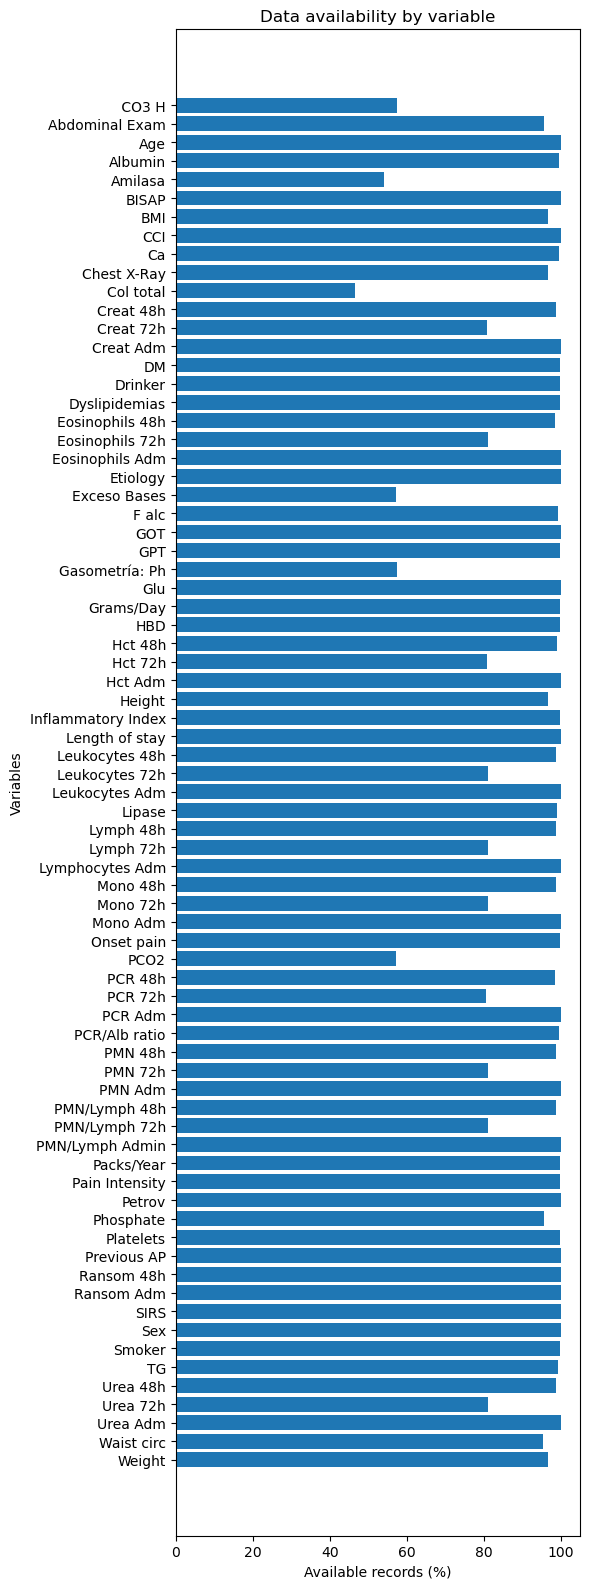

In [106]:
# Calculate the percentage of non-null values in each column
non_null_percentages = df.notna().mean() * 100

# Create a tidy DataFrame for display and plotting
non_null_data = (
    non_null_percentages
    .rename("available_%")
    .reset_index()
    .rename(columns={"index": "variable"})
    .sort_values(by="variable", ascending=False)
    .reset_index(drop=True)
)

# Statisticas
mean_available = non_null_data["available_%"].mean()
std_available = non_null_data["available_%"].std(ddof=0)  # population SD
print(f"Mean ± SD of available data: {mean_available:.2f}% ± {std_available:.2f}%")

# Plot
fig, ax = plt.subplots(figsize=(6, 16))

ax.barh(non_null_data["variable"], non_null_data["available_%"])
ax.set_xlabel("Available records (%)")
ax.set_ylabel("Variables")
ax.set_title("Data availability by variable")

plt.tight_layout()
plt.show()

The first issue identified in this dataset is the presence of missing values.
To address this limitation, imputation techniques can be applied to estimate the missing entries and enable the use of machine-learning models that require complete data.

Scikit-learn provides several imputation strategies, including mean, median, k-nearest neighbors, and multivariate approaches.
Further details can be found in the official documentation:
https://scikit-learn.org/stable/modules/impute.html#impute

### Target variablw distribution

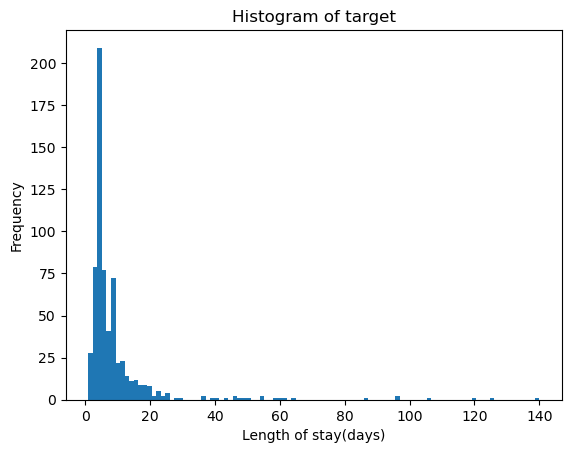

In [109]:
plt.figure()
plt.hist(df[y_column], bins=100)
plt.xlabel(y_column + "(days)")
plt.ylabel('Frequency')
plt.title('Histogram of target')
plt.show()

From the histogram, it can be observed that the distribution of the target variable (LOS) is **skewed to the right** (positively skewed), meaning that:
- Most patients have relatively short hospital stays
- A small number of patients present **very long stays** (long tail)

### Should we apply a log transformation?

Given the right-skewed distribution, applying a **logarithmic transformation** can be beneficial:

$y' = \log(1 + y)$

Advantages:
- Reduces the impact of extreme values (outliers)
- Makes the distribution more symmetric (closer to normal)
- Often improves model performance, especially for models sensitive to distribution shape

Considerations:
- Predictions will be made in log-space, so they must be transformed back:
$y = \exp(y') - 1$
- Interpretation becomes less direct
- Evaluation metrics should ideally be computed in the original scale


Recomendations:

- If the skewness is **moderate**, tree-based models (e.g., XGBoost) may handle it well without transformation
- If the skewness is **strong**, applying a log transformation is usually a good idea

A good practice is to **try both approaches** and compare performance using MAE/RMSE

# Evaluation Metrics for Length of Stay (LOS) Prediction

In this project, we aim to predict the **Length of Stay (LOS)** in days using clinical analytical data. Since LOS is a **continuous variable**, this is a **regression problem**.

To evaluate the performance of our model, we use three complementary metrics:



###  Mean Absolute Error (MAE)

The **Mean Absolute Error (MAE)** measures the average absolute difference between the predicted and true values:

$MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$

Interpretation:
- Expressed in **days**
- Easy to understand: *“On average, the model makes an error of X days”*

Advantages:
- Robust to outliers (important for LOS data)
- Clinically interpretable

Limitations:
- Does not penalize large errors more than small ones



### Root Mean Squared Error (RMSE)

The **Root Mean Squared Error (RMSE)** gives more weight to large errors:

$ RMSE = \sqrt{ \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 } $ 

Interpretation:
- Also expressed in **days**
- Penalizes large deviations more strongly

Advantages:
- Useful when large prediction errors are particularly undesirable
- Sensitive to outliers (can be a feature, not a bug)

Limitations:
- Less robust to extreme values
- Slightly less intuitive than MAE


###  R² Score (Coefficient of Determination)

The **R² score** measures how much of the variance in the data is explained by the model:

$ R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$ 

Interpretation:
- Ranges from **-∞ to 1**
- Values closer to **1** indicate better performance

Advantages:
- Widely used in scientific literature
- Gives a sense of model explanatory power

Limitations:
- Not directly interpretable in clinical units
- Can be misleading with skewed data (common in LOS)



### Practical Recommendation

For clinical regression problems like LOS:
- **Primary metric** → MAE (most interpretable)
- **Secondary metrics** → RMSE and R²

- **Bland Atman plot**: this plot is design to assess agreement between two measurement methods (predicted vs observed). It reports mean bias (does the model systematically over/understimate LOS?)  and 95% Limits of Agreement (LOA) (how large are the thypcial error (95 % interval)?. It also provides a measure of heteroscedasticity (do errors grow with longer stays?). For this target variable (right skewed with long tails), Bland Atlman plot is great to reveal patterns that MAE/RMSE hide.
- Consider additional analyses if LOS is highly skewed:
  - Error distribution plots
  - Clinically meaningful thresholds (e.g., error < 2 days)


No single metric tells the full story.  Combining MAE, RMSE, and R² provides a more complete and reliable evaluation of model performance.

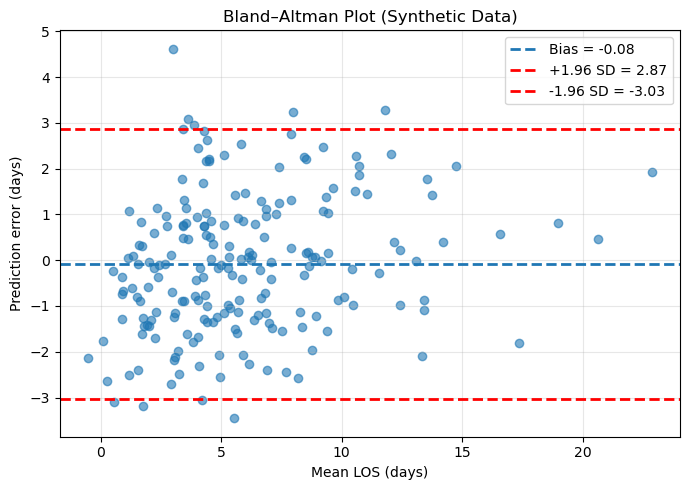

In [113]:
# Example of bladn atman plot
import numpy as np
import matplotlib.pyplot as plt

# Data simulation
np.random.seed(42)
n = 200
y_true = np.random.gamma(shape=2, scale=3, size=n)  # skewed distribution
y_pred = y_true + np.random.normal(0, 1.5, size=n)  # add noise to the y_true

# Calculate bland-atlamn data
mean = (y_true + y_pred) / 2
diff = y_pred - y_true

bias = np.mean(diff)
std = np.std(diff)

loa_upper = bias + 1.96 * std
loa_lower = bias - 1.96 * std

# Plot it
plt.figure(figsize=(7,5))
plt.scatter(mean, diff, alpha=0.6)
plt.axhline(bias, linestyle='--', linewidth=2, label=f'Bias = {bias:.2f}')
plt.axhline(loa_upper, linestyle='--', color='red', linewidth=2, label=f'+1.96 SD = {loa_upper:.2f}')
plt.axhline(loa_lower, linestyle='--', color='red', linewidth=2, label=f'-1.96 SD = {loa_lower:.2f}')

plt.xlabel('Mean LOS (days)')
plt.ylabel('Prediction error (days)')
plt.title('Bland–Altman Plot (Synthetic Data)')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Validation strategy

To ensure a robust and unbiased evaluation of the predictive model, a structured validation strategy was adopted.

1.  Train–Test Split

The dataset was initially divided into training and test subsets using an **80/20 split**.  
Given that the target variable (*Length of Stay, LOS*) exhibits a **right-skewed distribution**, a standard random split could lead to imbalanced representations of short and long hospital stays across subsets.

To address this, a **stratified splitting approach for regression** was implemented:

- The continuous LOS variable was discretized into **quantile-based bins** using `qcut` (10 bins).
- These bins were then used to perform a **stratified train–test split**, ensuring a similar distribution of LOS values in both subsets.

This approach improves the representativeness of the test set, particularly in the presence of skewed target distributions.

To verify the effectiveness of the stratified splitting strategy, the distribution of LOS was visually inspected in both training and test sets using histograms. Comparable distributions indicate that the split preserves the underlying structure of the data.


The use of **stratified splitting in regression problems with skewed targets** is not yet standard practice but is increasingly recommended in the literature. 


2. Cross-Validation (CV)

Within the training set, model performance was further assessed using **K-fold cross-validation**, which is considered a standard approach in machine learning:

- The training data were partitioned into *K* equally sized folds (typically \(K=5\) or \(K=10\)).
- At each iteration, the model was trained on \(K-1\) folds and validated on the remaining fold.
- This process was repeated *K* times, and the results were averaged to obtain a more stable estimate of model performance.

Cross-validation helps mitigate variance due to data partitioning and provides a more reliable assessment of generalization performance.




In [ ]:
Example:
from sklearn.model_selection import train_test_split
df['los_bin'] = pd.qcut(df[y_column], q=10, labels=False, duplicates = 'drop')
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['los_bin'],
    random_state=42
)

train_df = train_df.drop(columns=['los_bin'])
test_df = test_df.drop(columns=['los_bin'])

fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=True)

# Train
axes[0].hist(train_df[y_column], bins=100)
axes[0].set_title('Train set')
axes[0].set_xlabel(f'{y_column} (days)')
axes[0].set_ylabel('Frequency')

# Test
axes[1].hist(test_df[y_column], bins=100)
axes[1].set_title('Test set')
axes[1].set_xlabel(f'{y_column} (days)')

plt.tight_layout()
plt.show()